# Martian Spiders

In [47]:
import os
import sys
import matplotlib.pyplot as plt
from brokenaxes import brokenaxes 
import pdb
import numpy as np
import os as os_module
from scipy.integrate import solve_ivp
import pandas as pd
from matplotlib import ticker
import scipy as sp
from scipy.integrate import cumulative_trapezoid, trapezoid, odeint, solve_bvp, solve_ivp
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib import colormaps
import matplotlib.ticker as mtick
from matplotlib.ticker import EngFormatter, LogLocator, FuncFormatter, NullFormatter, FixedLocator, StrMethodFormatter, LogFormatter, LogFormatterSciNotation, LogFormatterExponent, LogFormatterMathtext, FixedFormatter
from matplotlib.lines import lineStyles
import cmocean
import cmocean.cm as cmo
from matplotlib.colors import LogNorm
from IPython.display import clear_output
import matplotlib.patheffects as pe
from matplotlib.collections import LineCollection
from labellines import labelLines
from itertools import cycle

Text(0.5, 1.0, 'e-folding scale $Z$ as a function of grain diameter $d$')

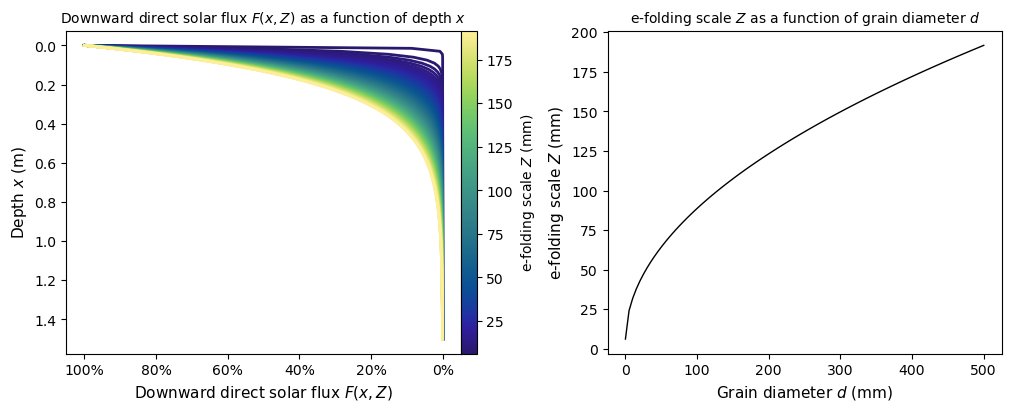

In [58]:
# Chinnerny et al. (2020) found e-folding of solar radiation penetration in CO2 ice relates to grain size in the following way.
 
a = 5.37 # (mm)
b_CO2 = 0.0144 # (mm)
d = np.linspace(1e-2, 500, 100) # grain diameter (mm)
# CO2 ice slab thicknesses: ~0.5-1 m.
x = np.linspace(0, 1.5, 100)*1e3 # depth (mm)

Z = a + np.sqrt(d/b_CO2) # e-folding scale 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

# and downward direct energy flux F(x,Z) as a percentage of total radiation is given by
colors = cmocean.cm.haline(np.linspace(0, 1, len(Z)))
for i, z in enumerate(Z):
    F = np.exp(-x / z)
    ax1.plot(F*1e2, x/1e3, lw=2, color=colors[i], label=f'$Z={z:.0f}$ mm')
ax1.set_ylabel('Depth $x$ (m)', fontsize=11)
ax1.set_xlabel('Downward direct solar flux $F(x,Z)$', fontsize=11)
ax1.xaxis.set_major_formatter(mtick.PercentFormatter())
# ax1.grid(lw=0.3)
ax1.invert_yaxis()
ax1.invert_xaxis()
sm = plt.cm.ScalarMappable(cmap=cmocean.cm.haline)
sm.set_array(Z)
fig.colorbar(sm, ax=ax1, label='e-folding scale $Z$ (mm)', orientation='vertical', shrink=1, pad=0)
# ax1.legend(loc='lower left', fontsize=10, frameon=True, fancybox=True, edgecolor='black', facecolor='w')
ax1.set_title('Downward direct solar flux $F(x,Z)$ as a function of depth $x$', fontsize=10)

ax2.plot(d, Z, color='k', lw=1)
ax2.set_xlabel('Grain diameter $d$ (mm)', fontsize=11)
ax2.set_ylabel('e-folding scale $Z$ (mm)', fontsize=11)
ax2.set_title('e-folding scale $Z$ as a function of grain diameter $d$', fontsize=10)
# ax2.grid(lw=0.3)


In [49]:
# What depths correspond to 20%, 50%, 90%, and 99% of the flux for a given grain size?
thresholds = [0.8, 0.5, 0.2, 0.1, 0.01]
z = Z[50] # grain size (mm)
depths = {p:-z*np.log(p)/1e3 for p in thresholds}
print(f"Grain size: ~{d[50]:.0f} mm, \ne-folding scale: ~{z:.0f} mm")
print(f"___________________ \n20% flux depth: {depths[0.8]:.3f} m")
print(f"50% flux depth: {depths[0.5]:.3f} m")
print(f"80% flux depth: {depths[0.2]:.3f} m")
print(f"90% flux depth: {depths[0.1]:.3f} m")
print(f"99% flux depth: {depths[0.01]:.3f} m \n___________________")

Grain size: ~253 mm, 
e-folding scale: ~138 mm
___________________ 
20% flux depth: 0.031 m
50% flux depth: 0.096 m
80% flux depth: 0.222 m
90% flux depth: 0.317 m
99% flux depth: 0.635 m 
___________________


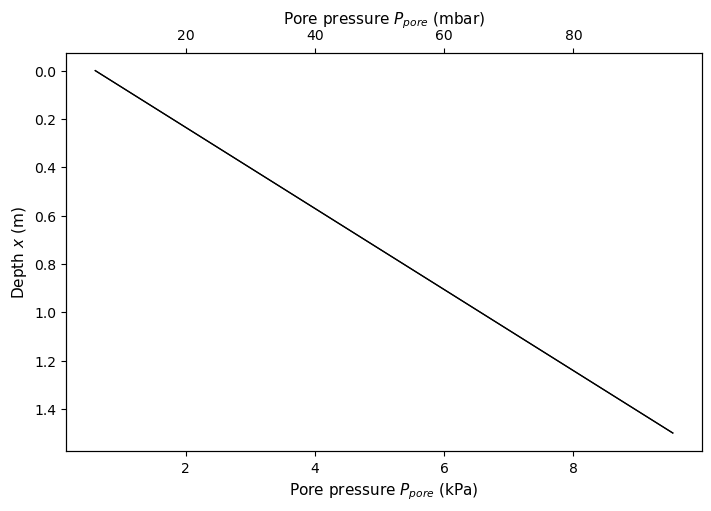

In [50]:
# Evolution of substrate pore pressure with depth

P_surf = 600 # (Pa) surface pressure on Mars
density_ice = 1606 # (kg/m3)
g = 3.71 # (m/s2)

P_pore = P_surf + density_ice * g * x/1e3 # (Pa) for a depth x (mm)
P_pore_kPa = P_pore/1e3
P_pore_mbar = P_pore_kPa*10

fig, ax1 = plt.subplots(figsize=(7, 5), constrained_layout=True)
ax2 = ax1.twiny()

ax1.plot(P_pore_kPa, x/1e3, color='k', lw=0.9)
ax2.plot(P_pore_mbar, x/1e3, color='k', lw=0.9)
ax1.set_ylabel('Depth $x$ (m)', fontsize=11)
ax1.set_xlabel('Pore pressure $P_{pore}$ (kPa)', fontsize=11)
ax2.set_xlabel('Pore pressure $P_{pore}$ (mbar)', fontsize=11)

# ax1.grid(color='k', lw=0.1)
ax1.invert_yaxis()

Text(0.5, 1.0, 'gas production (GP) radius as a function of GP area')

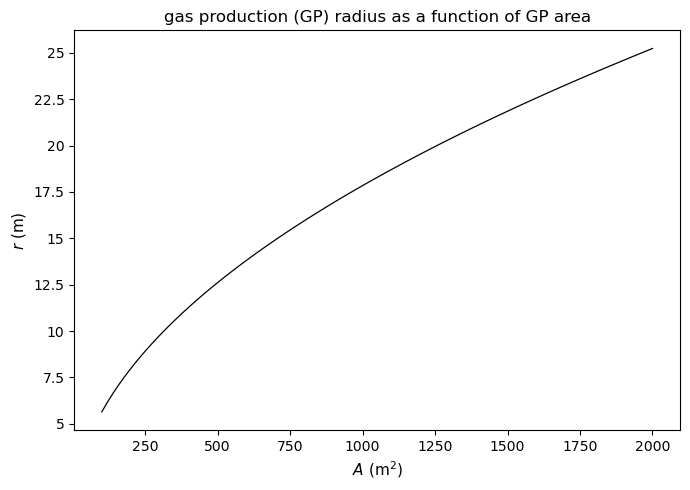

In [51]:
# area of a circle is A = pi*r**2

areas = np.linspace(1e2,2e3, 100) # (m2)
r = np.sqrt(areas/np.pi) # (m)
R = r

fig, ax = plt.subplots(layout='tight', figsize=(7,5))
# ax2 = ax.twiny()

ax.plot(areas, r, color='k', lw=0.9)
# ax2.plot(areas/1e6, r, color='k', lw=0.9)
ax.set_xlabel('$A$ (m$^2$)', fontsize=11)
# ax2.set_xlabel('$A$ (km$^2$)', fontsize=11)
ax.set_ylabel('$r$ (m)', fontsize=11) 
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:g}'))
ax.set_title('gas production (GP) radius as a function of GP area', fontsize=12)
# ax.grid(color='k', lw=0.1)


Text(0.5, 1.0, 'critical pressure for fracture as a function of r/R')

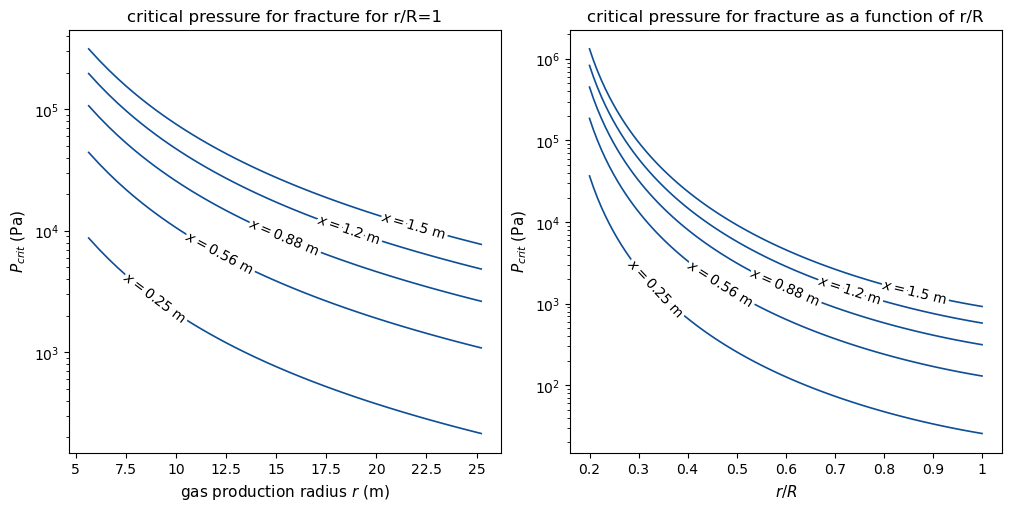

In [60]:
# critical pressure for fracture and eruption from Portyankina et al. (2010)'s plate-mechanics model 

sigma = 12.3e6 # (Pa) tensile strength of CO2 ice, or maximum "bending stress"
nu = 0.544 # Poisson's ratio for CO2 ice
# R: either define a constant R or run the previous cell
# x = 1.5e3 # (mm) slab thickness
# linestyles = ['-', '--', (5, (10,3)), ':', (0, (3, 1, 1, 1))]

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)

# left plot: critical pressure as a function of r, R, and x, for a series of thicknesses
for i, x in enumerate(np.linspace(0.25, 1.5, 5)):
    r = np.sqrt(areas/np.pi) # (m)
    P_crit = 8 * sigma * (x)**2 / (3 * r**2) * 1/(4 - (1 - nu) * (r/R)**2 + 4 * (1 + nu) * np.log(R/r))
    ax.semilogy(r, P_crit, color=cmo.haline(0.2), lw=1.2, ls='-', label=f'$x={x:.2g}$ m')

labelLines(ax.get_lines(), align=True, fontsize=10, color='k')
ax.set_ylabel('$P_{crit}$ (Pa)', fontsize=11)
ax.set_xlabel('gas production radius $r$ (m)', fontsize=11)
# ax.grid(color='k', lw=0.1)
ax.xaxis.set_major_formatter(StrMethodFormatter('{x:g}'))
ax.yaxis.set_major_formatter(LogFormatterSciNotation(base=10.0, labelOnlyBase=False))
# ax.legend(title='slab thicknesses')
# ax.invert_yaxis()
ax.set_title('critical pressure for fracture for r/R=1', fontsize=12)

# right plot: critical pressure as a function of r/R for a given slab thickness
for i in enumerate(np.linspace(0.25, 1.5, 5)):
    idx, x = i
    R = np.linspace(10, 150, 100)
    r = np.linspace(0.2, 1, 100)*R
    P_crit = 8 * sigma * (x)**2 / (3 * r**2) * 1/(4 - (1 - nu) * (r/R)**2 + 4 * (1 + nu) * np.log(R/r))
    ax2.semilogy(r / R, P_crit, color=cmo.haline(0.2), lw=1.2, ls='-', label=f'$x={x:.2g}$ m')

labelLines(ax2.get_lines(), align=True, fontsize=10, color='k')
ax2.set_ylabel('$P_{crit}$ (Pa)', fontsize=11)
ax2.set_xlabel('$r/R$', fontsize=11)
# ax2.grid(color='k', lw=0.1)
ax2.xaxis.set_major_formatter(StrMethodFormatter('{x:g}'))
ax2.set_title('critical pressure for fracture as a function of r/R', fontsize=12)

# for small r/R, more gas pressure (higher gas production time) must be added to achieve the same amount of pressure

Text(0.5, 1.0, 'Attree et al. (2021) Fig. 3')

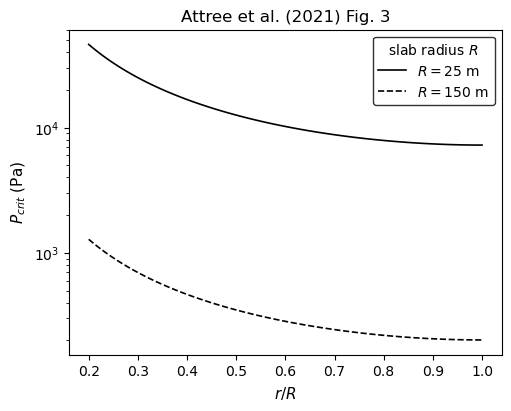

In [53]:
# replicating their figure 3:
# Gas pressure required to fracture a sheet of CO2 ice of thickness x=0.7 and radius R for different scales of gas buildup area r.

import enum


R = 150 # (m) radius of the CO2 ice sheet
x = 0.7 # (m) slab thickness
colors = [cmo.haline(0.6), cmo.thermal(0.8)]
lines = ['-', '--']

fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)
for i, R in enumerate([25, 150]):
    r = np.linspace(0.2, 1, 100)*R # (m) gas production radius
    P_crit = 8 * sigma * (x)**2 / (3 * r**2) * 1/(4 - (1 - nu) * (r/R)**2 + 4 * (1 + nu) * np.log(R/r))
    ax.semilogy(r/R, P_crit, color='k', lw=1.2, ls=lines[i], label=f'$R={R:.0f}$ m')

ax.set_ylabel('$P_{crit}$ (Pa)', fontsize=11)
ax.yaxis.set_major_formatter(LogFormatterSciNotation(base=10.0, labelOnlyBase=False))
ax.legend(title='slab radius $R$', fontsize=10, frameon=True, fancybox=True, edgecolor='black', facecolor='w')
ax.set_xlabel('$r/R$', fontsize=11)
ax.set_title('Attree et al. (2021) Fig. 3')

In [54]:
# Gudmundsson (2022) describes the pressure conditions at the time of fracture of a reservoir overlain by a layer as

# the sum of
pl = P_pore # (Pa) ambient pressure in the static reservoir 
# pe (Pa): some excess pressure generated by gas production
# must equal the sum of 
# sigma3 (Pa): the least compressive, greatest tensile stress (+),
T0 = - sigma # (Pa) local in situ tensile strength (-)

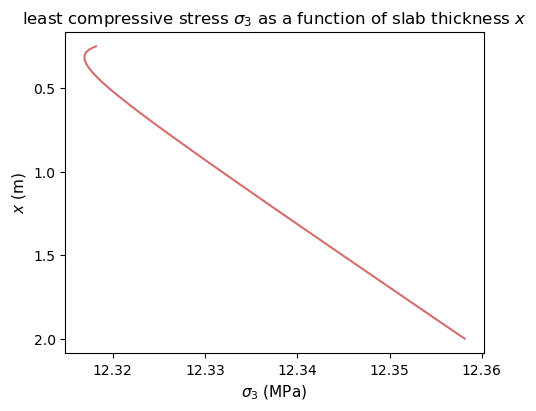

In [55]:
# solving for the maximum tensile stress σ3

# the critical pressure was given by the Portyankina et al. (2010) formulation above
# P_crit = pl + pe, since P_crit represents the total fluid pressure in the source
# so, we solve for σ3 as σ3 = P_crit - T0

x = np.linspace(0.25, 2, 100) # (m) slab thicknesses
R = np.sqrt(areas/np.pi) # (m)
# r = np.linspace(1e-2, 1, 100)*R # (m) gas production radius
r = R
P_crit = 8 * sigma * (x)**(2)/(3 * r**2) * 1/(4 - (1 - nu) * (r/R)**2 + 4 * (1 + nu) * np.log(R/r))
sigma3 =  P_crit - T0

fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)
ax.plot(sigma3/1e6, x, color=cmo.thermal(0.6))
ax.set_ylabel('$x$ (m)', fontsize=11)
ax.set_xlabel('$\sigma_3$ (MPa)', fontsize=11)
# ax.grid(color='k', lw=0.1)
ax.set_title('least compressive stress $\sigma_3$ as a function of slab thickness $x$', fontsize=12)
ax.yaxis.set_major_locator(FixedLocator([0, 0.5, 1, 1.5, 2]))
ax.xaxis.set_major_formatter(StrMethodFormatter('{x:g}'))
ax.invert_yaxis()

# tensile stress increases with depth because the critical pressure is proportional to the square of the slab thicknes x
# the thicker the slab, the more the slab can bend before fracturing

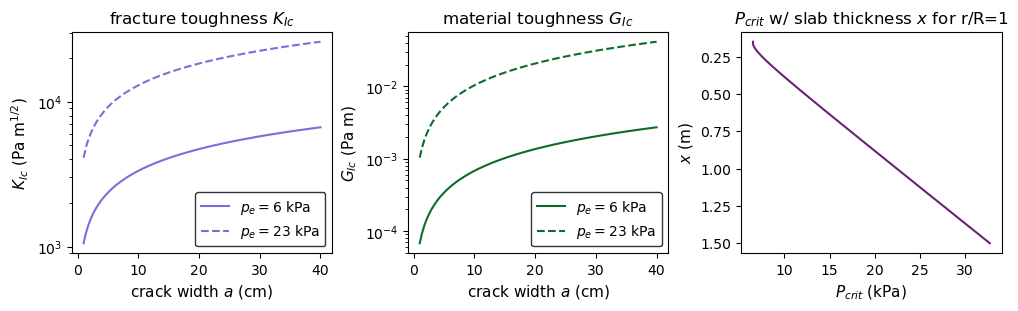

In [45]:
# BIG ISSUE: very few constraints on CO2 ice material properties (e.g., toughness)

# Estimating fracture toughness of CO2 ice using Gudmundsson (2022)

x = np.linspace(0.15, 1.5, 100) # (m) slab thicknesses
R = np.sqrt(areas/np.pi) # (m)
r = R
P_crit = 8 * sigma * (x)**(2)/(3 * r**2) * 1/(4 - (1 - nu) * (r/R)**2 + 4 * (1 + nu) * np.log(R/r))
pe = P_crit - P_pore # (Pa) excess pressure generated by gas production
a = np.linspace(1e-2, 4e-1, 100) # (m) sweep of putative crack widths, going off of Thomas et al. (2011) who used a 20 cm width

fig, (ax, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 3), constrained_layout=True)
lines = ['-', '--']

# fracture toughness KIc
for i, p in enumerate([pe[0], pe[-1]]):
    KIc = p * np.sqrt(np.pi * a) # (Pa m^0.5) fracture toughness of CO2 ice
    ax.semilogy(a*1e2, KIc, color=cmo.dense(0.5), ls=lines[i], label=f'$p_{{e}}={p/1e3:.0f}$ kPa')

ax.set_xlabel('crack width $a$ (cm)', fontsize=11)
ax.set_ylabel('$K_{Ic}$ (Pa m$^{1/2}$)', fontsize=11)
# ax.grid(color='k', lw=0.1)
ax.set_title('fracture toughness $K_{Ic}$', fontsize=12)
ax.yaxis.set_major_formatter(LogFormatterSciNotation(base=10.0, labelOnlyBase=False))
# ax.yaxis.set_major_formatter(StrMethodFormatter('{x:g}'))
ax.legend(fontsize=10, frameon=True, fancybox=True, edgecolor='black', facecolor='w')

# material toughness GIc
E = 11.5e9 # (Pa) Young's modulus of CO2 ice (Yamashita and Kato, 1997)

for i, p in enumerate([pe[0], pe[-1]]):
    GIc = p**2 * np.pi * a * (1-nu**2) / E
    # dimensional analysis: GIc = 
    ax2.semilogy(a*1e2, GIc, color=cmo.speed(0.7), ls=lines[i], label=f'$p_{{e}}={p/1e3:.0f}$ kPa')

ax2.set_xlabel('crack width $a$ (cm)', fontsize=11)
ax2.set_ylabel('$G_{Ic}$ (Pa m)', fontsize=11)
# ax2.grid(color='k', lw=0.1)
ax2.set_title('material toughness $G_{Ic}$', fontsize=12)
ax2.yaxis.set_major_formatter(LogFormatterSciNotation(base=10.0, labelOnlyBase=False))
ax2.legend(fontsize=10, frameon=True, fancybox=True, edgecolor='black', facecolor='w')

# P_crit as a function of slab thickness x for r/R=1
ax3.plot(P_crit/1e3, x, color=cmo.dense(0.8))
ax3.set_ylabel('$x$ (m)', fontsize=11)
ax3.set_xlabel('$P_{crit}$ (kPa)', fontsize=11)
# ax3.grid(color='k', lw=0.1)
ax3.set_title('$P_{{crit}}$ w/ slab thickness $x$ for r/R=1')
ax3.xaxis.set_major_formatter(StrMethodFormatter('{x:g}'))
ax3.invert_yaxis()

In [ ]:
# from Chivers et al (2021), drawing from Michaut and Manga (2017)

# strain, dimensionless, DV/V